In [1]:
import numpy as np
import pandas as pd 
from epiweeks import Week
from numpy import log, exp
from itertools import product 
import matplotlib.pyplot as plt 
import matplotlib as mpl

# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 16 # Axis labels
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick labels
plt.rcParams['font.size'] = 16  # General font size
FONT = 12


In [2]:
dict_models_name = {157: 'UERJ-SARIMAX-2', 156: 'Dengue oracle M2', 155: 'Dengue Oracle M1', 135:'GHR Model', 
                    133:'Chronos-Bolt', 139: 'Cornell PEH', 143: 'Model fourier-\ngravidade', 144:'Beat it', 150: 'LNN-AR_p-1', 
        145: 'CNNLSTM' , 141: 'Kaust Geohealth', 136: 'Imperial-TFT Model', 137: 'LSTM-RF model', 
                    138: 'TSMixer ZKI-PH4', 154: 'LNCC-SURGE-1', 152: 'LNCC-CLIDENGO-1', 134: 'ISI_Dengue_Model', 108:'IMPA-TECH'} 

Load the data: 

In [3]:
data = pd.read_csv('predictions/dengue_agg.csv.gz')
data.date = pd.to_datetime(data.date)
data = data.sort_values(by = 'date')

data['valid_test'] = None

data.loc[(data.date >= Week(2022, 41).startdate().strftime('%Y-%m-%d')) & (data.date <= Week(2023, 40).startdate().strftime('%Y-%m-%d')), 'valid_test'] = '1'  

data.loc[(data.date >= Week(2023, 41).startdate().strftime('%Y-%m-%d')) & (data.date <= Week(2024, 40).startdate().strftime('%Y-%m-%d')), 'valid_test'] = '2'

data.loc[(data.date >= Week(2024, 41).startdate().strftime('%Y-%m-%d')) & (data.date <= Week(2025, 40).startdate().strftime('%Y-%m-%d')), 'valid_test'] = '3' 

df_agg = data.dropna().groupby(['uf', 'valid_test'])[['casos']].sum().reset_index().rename(columns = {'uf': 'state'})
df_agg['valid_test'] = df_agg['valid_test'].astype(int)
df_agg.head()


,state,valid_test,casos
0,AC,1,4735.0
1,AC,2,9740.0
2,AC,3,11533.0
3,AL,1,4779.0
4,AL,2,18667.0


Loaf cumulative cases results:

In [4]:
df_cum_cases = pd.read_csv('results/cumulative_cases_ind_models_copule_method.csv.gz') 
df_cum_cases = df_cum_cases.rename(columns = {'model': 'model_id'})
df_cum_cases.head()

,state,model_id,valid_test,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95
0,AM,Dengue oracle M2,2,16759.842829,19701.124158,24026.087296,34369.616950,49203.015998,71907.113401,100553.149907,124257.278974,147251.373682
1,AM,Dengue oracle M2,1,9769.876925,11925.533606,14740.430641,21691.115654,32157.557516,47498.268247,70680.881515,89337.838726,114652.778921
2,AM,Dengue oracle M2,3,6896.698369,8399.579359,11136.912651,16783.524427,26255.407031,41140.491865,62087.388750,77388.479655,97357.538509
3,AM,Model fourier-\ngravidade,2,628.165746,867.406998,1316.435844,2621.167780,5761.137645,12542.765440,26246.975856,40511.251908,62233.499865
4,AM,Model fourier-\ngravidade,1,640.261728,891.307217,1293.693838,2610.876619,5735.525652,12229.364632,25173.544941,38695.322491,53439.963204


In [5]:
df_cum_cases_agg = df_cum_cases.merge(df_agg, on = ['state', 'valid_test'])

df_cum_cases_agg.head()

,state,model_id,valid_test,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,casos
0,AM,Dengue oracle M2,2,16759.842829,19701.124158,24026.087296,34369.616950,49203.015998,71907.113401,100553.149907,124257.278974,147251.373682,10105.0
1,AM,Dengue oracle M2,1,9769.876925,11925.533606,14740.430641,21691.115654,32157.557516,47498.268247,70680.881515,89337.838726,114652.778921,6279.0
2,AM,Dengue oracle M2,3,6896.698369,8399.579359,11136.912651,16783.524427,26255.407031,41140.491865,62087.388750,77388.479655,97357.538509,6150.0
3,AM,Model fourier-\ngravidade,2,628.165746,867.406998,1316.435844,2621.167780,5761.137645,12542.765440,26246.975856,40511.251908,62233.499865,10105.0
4,AM,Model fourier-\ngravidade,1,640.261728,891.307217,1293.693838,2610.876619,5735.525652,12229.364632,25173.544941,38695.322491,53439.963204,6279.0


In [6]:
def make_plot(ax, df_cum_cases, state, valid_test): 
    '''
    make the figure with the error bars 
    '''
    df_cum = df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == valid_test)]

    obs = df_cum.casos.values[0]

    ax.axhline(obs, color = 'black', linewidth =2, linestyle = '--', label = 'Data')
    
    x = df_cum.model_id.astype(str)
    y = df_cum.pred
    
    # compute symmetric errors from lower and upper bounds
    yerr = np.array([y - df_cum.lower_95, df_cum.upper_95 - y])

    for xi, yi, yierr, low, up in zip(x, y, yerr.T, df_cum.lower_95, df_cum.upper_95):
    # condition: observed is inside prediction interval
        if low <= obs <= up:
            ecolor = "tab:green"
        else:
            ecolor = "tab:red"
        
        ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color=ecolor, ecolor=ecolor, capsize=5)
        
    
    ax.set_ylabel('Cumulative cases')
    ax.set_xlabel('Model ID')
    
    ax.set_title(f'Validation test - {valid_test} - {state}')

    ax.set_ylim([0, max(2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 1)].casos.values[0],
                        2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 2)].casos.values[0], 
                        2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 3)].casos.values[0])])
    ax.grid()
    ax.legend()
    for label in ax.get_xticklabels():
        label.set_rotation(90)

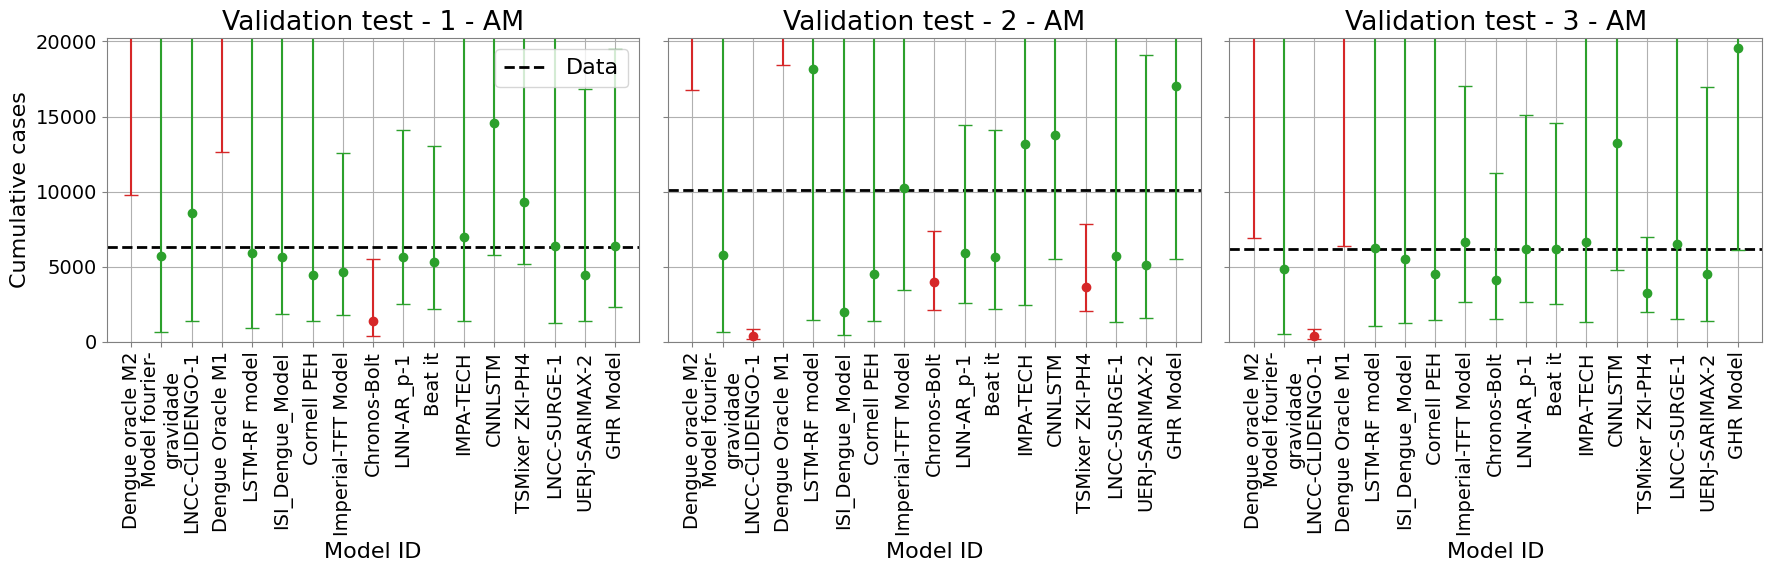

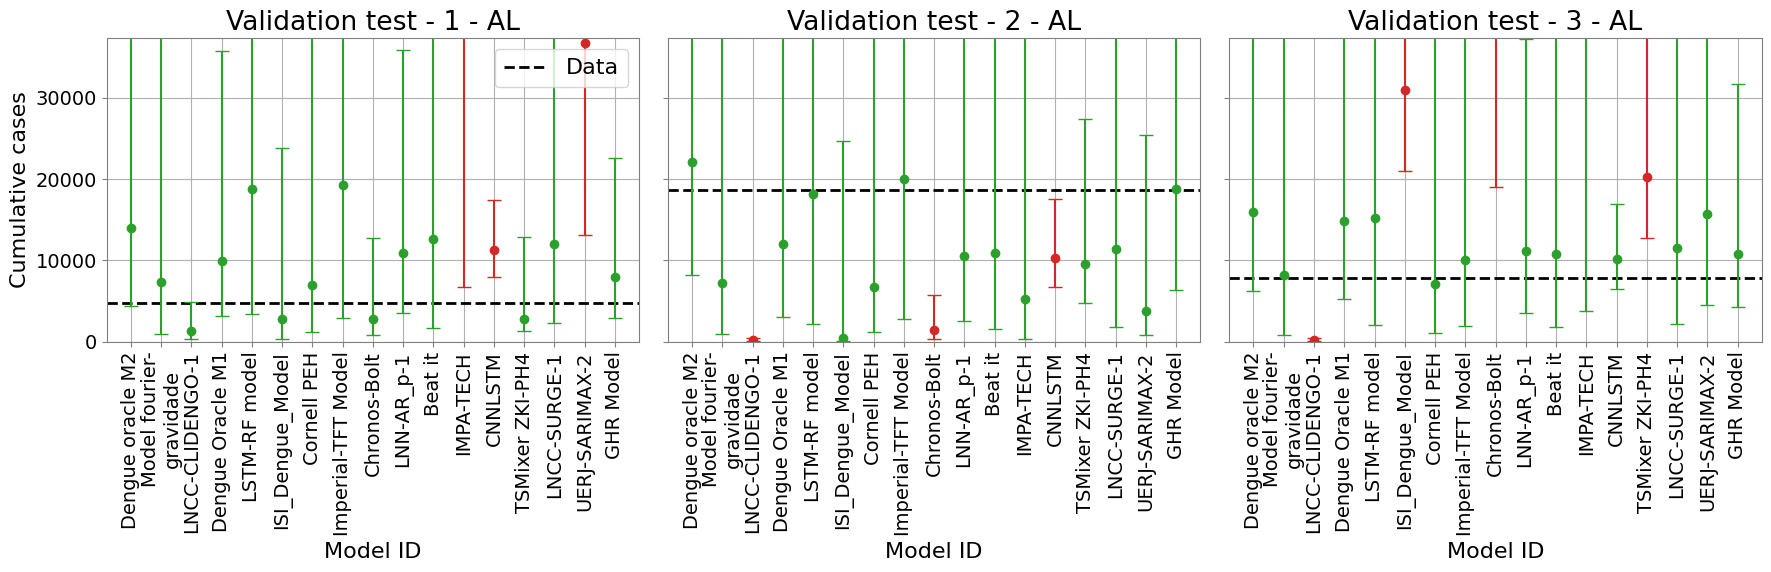

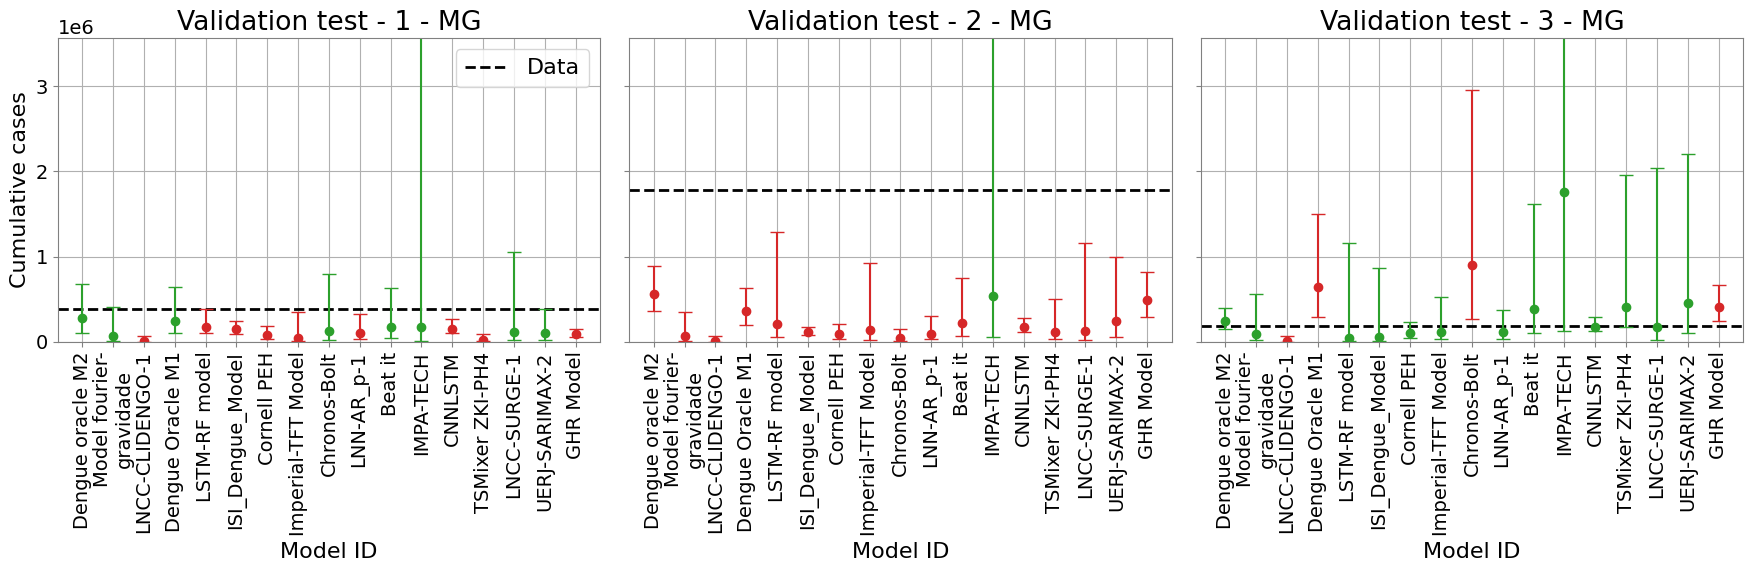

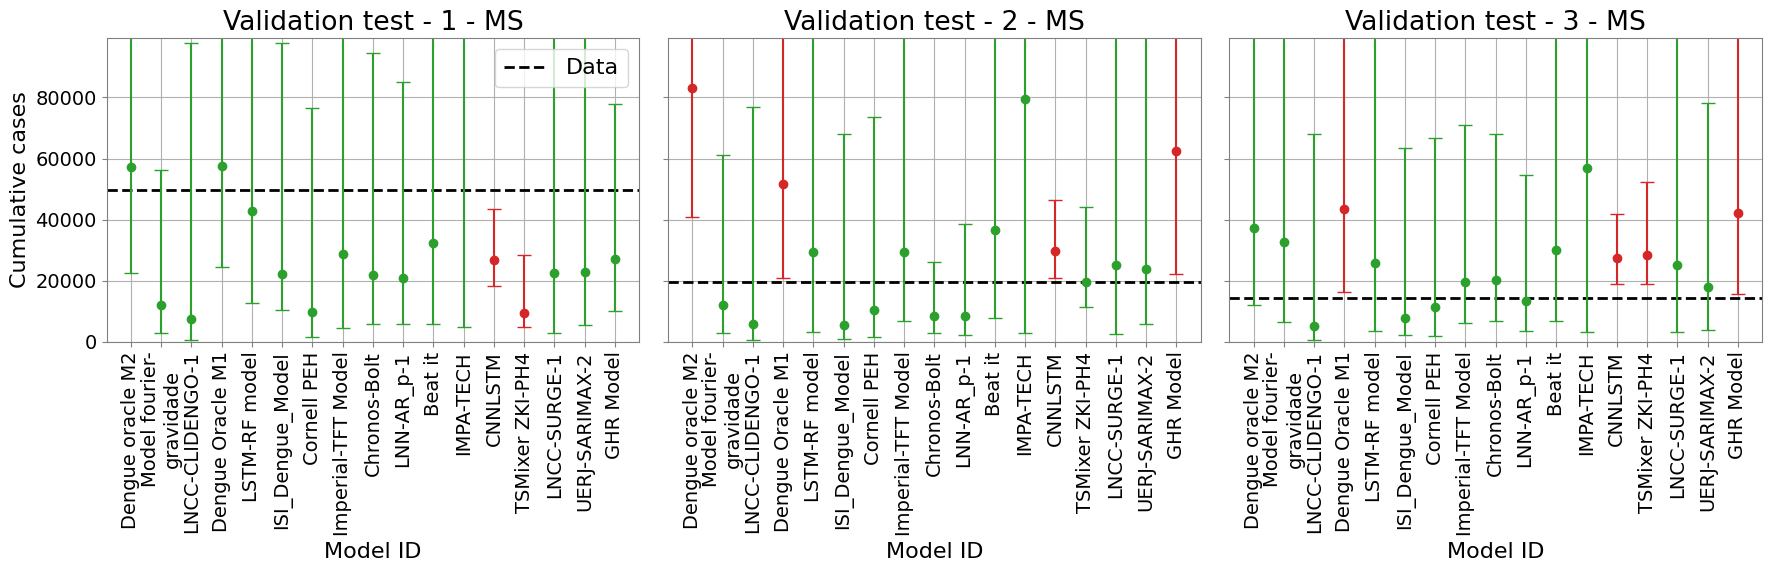

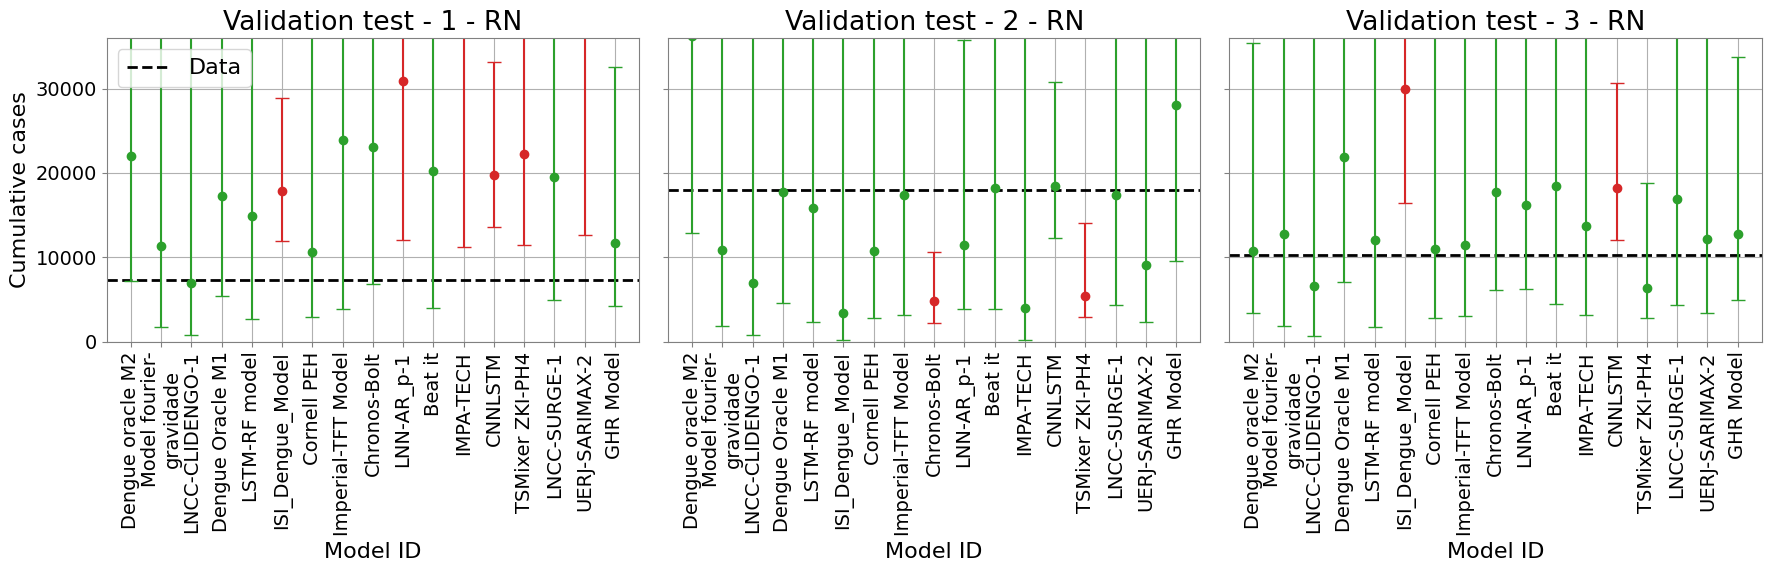

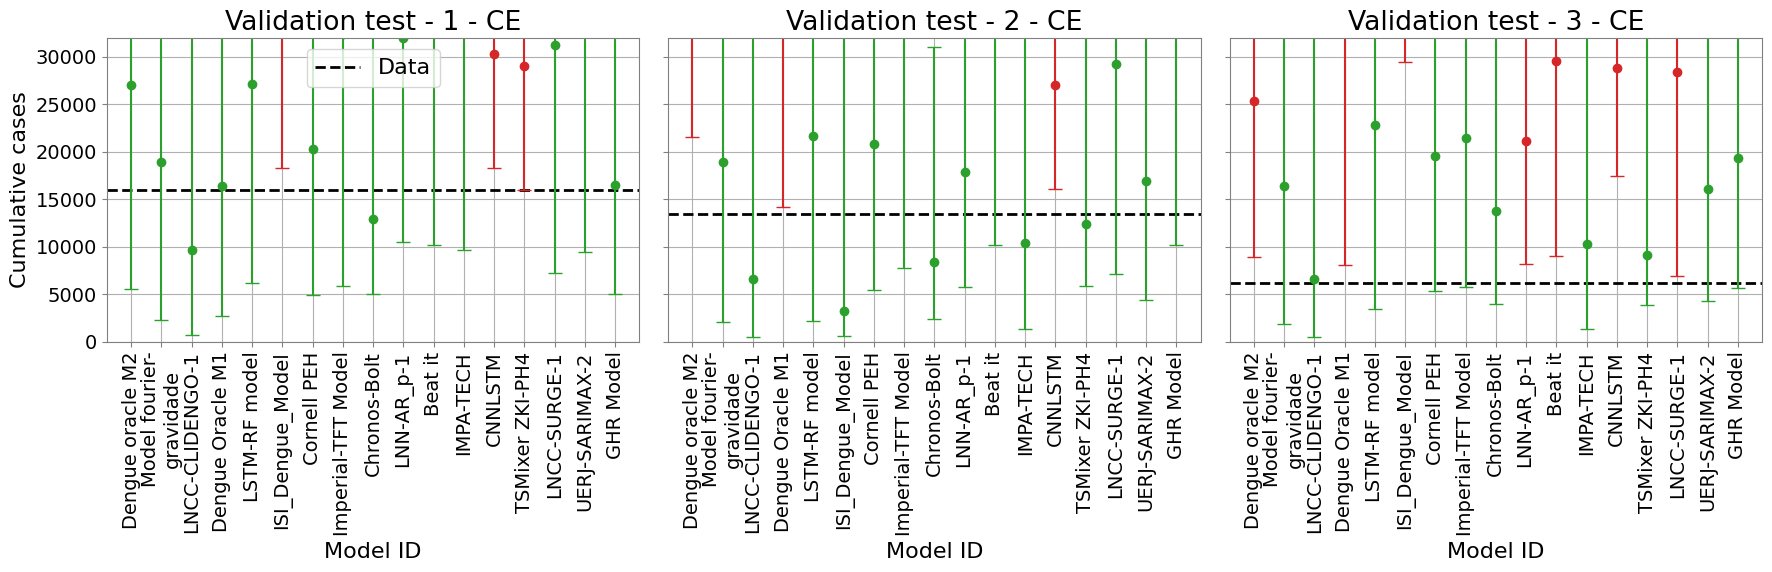

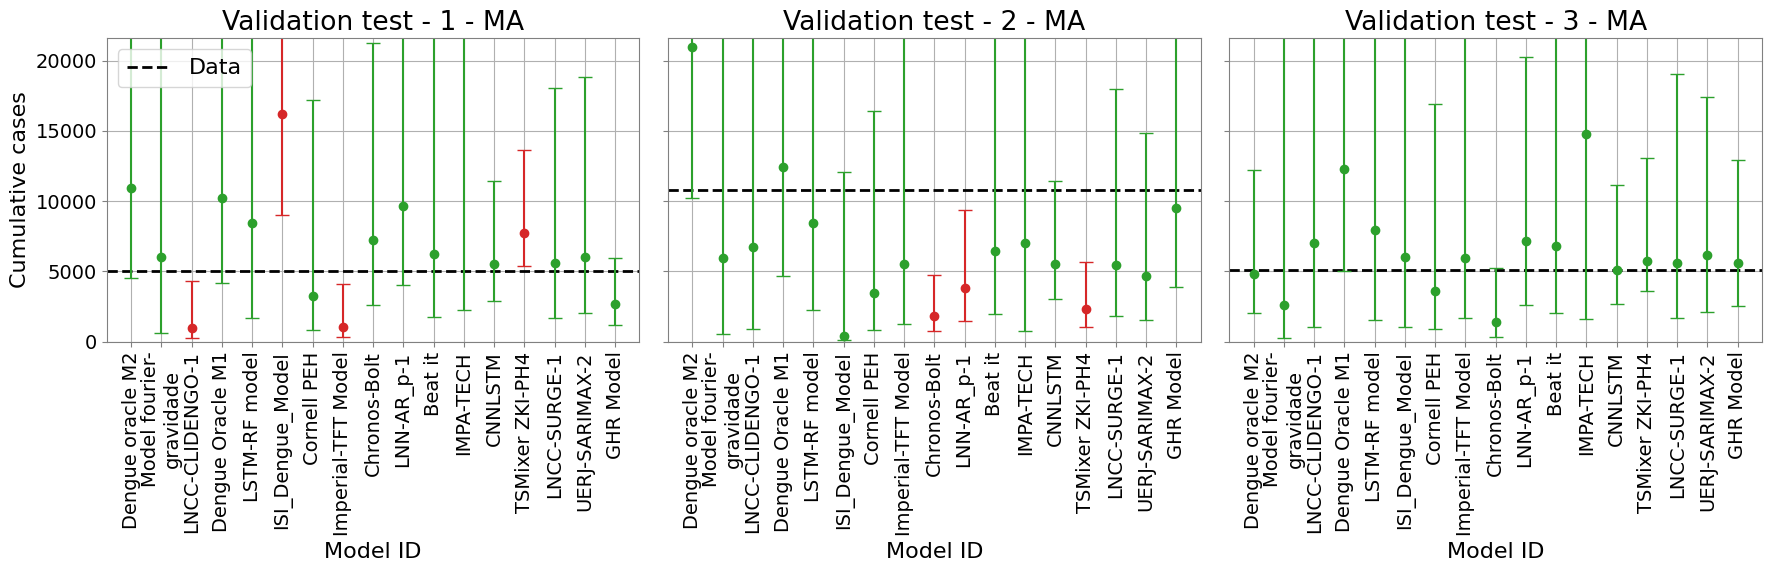

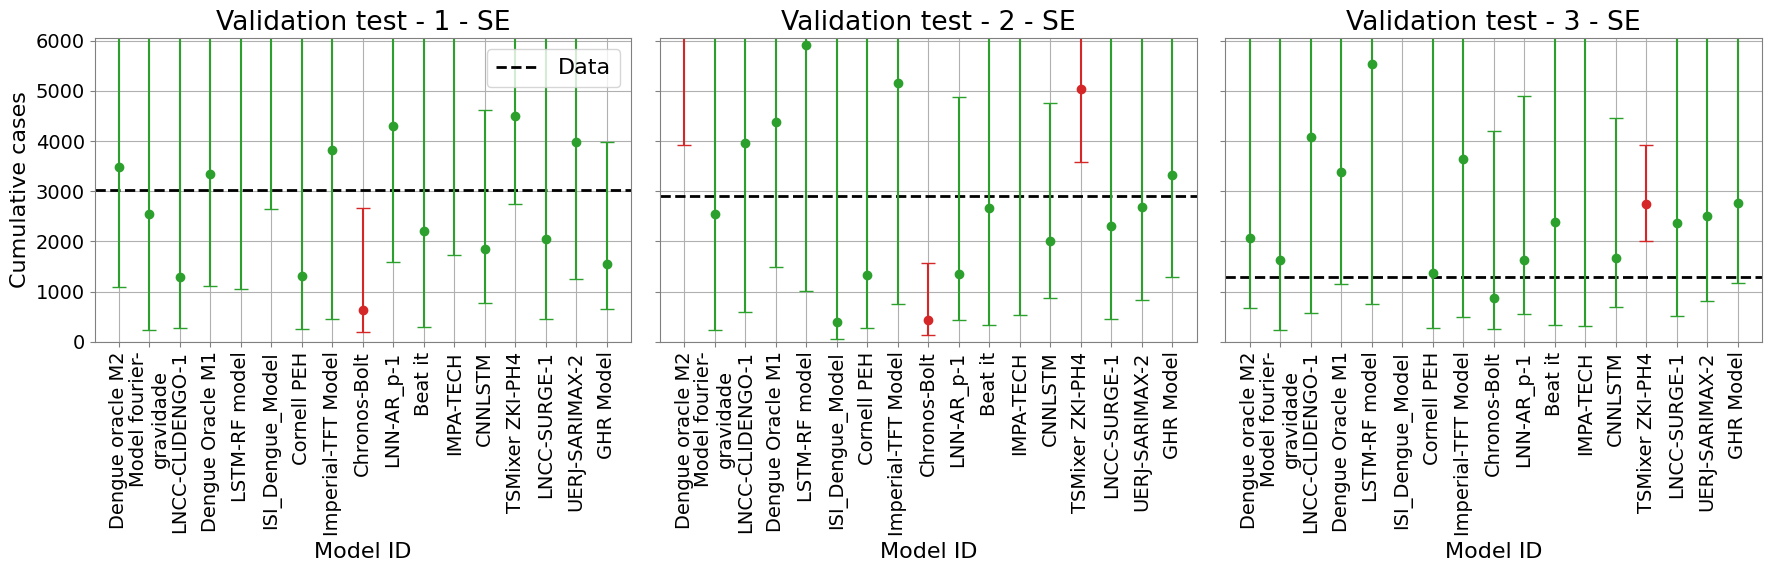

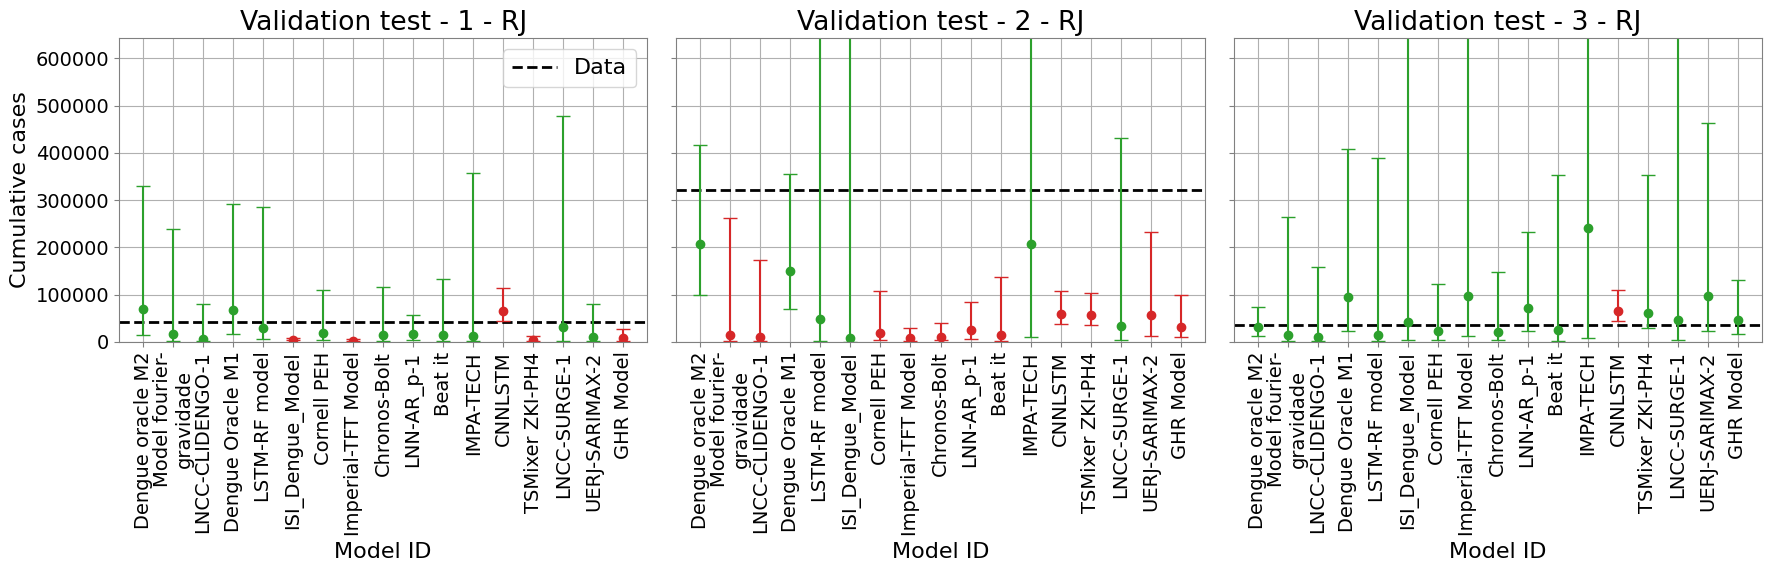

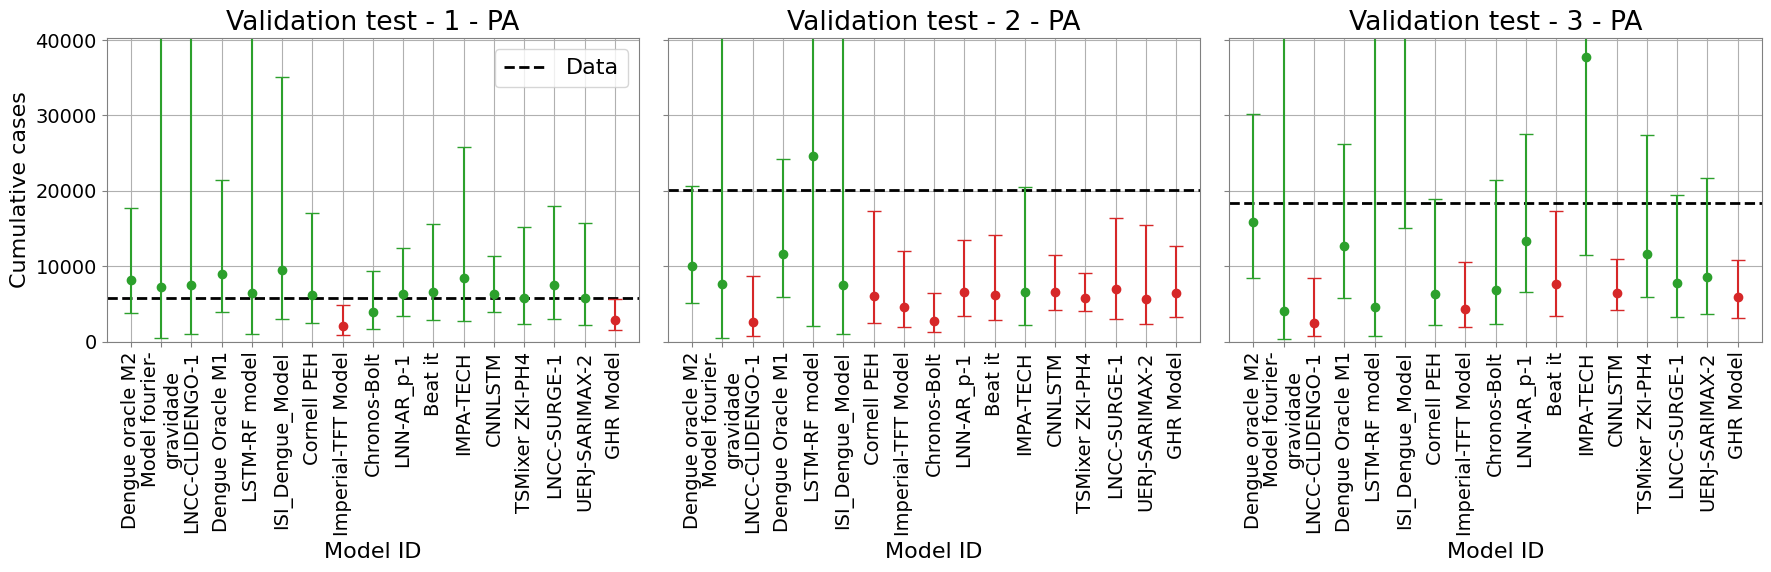

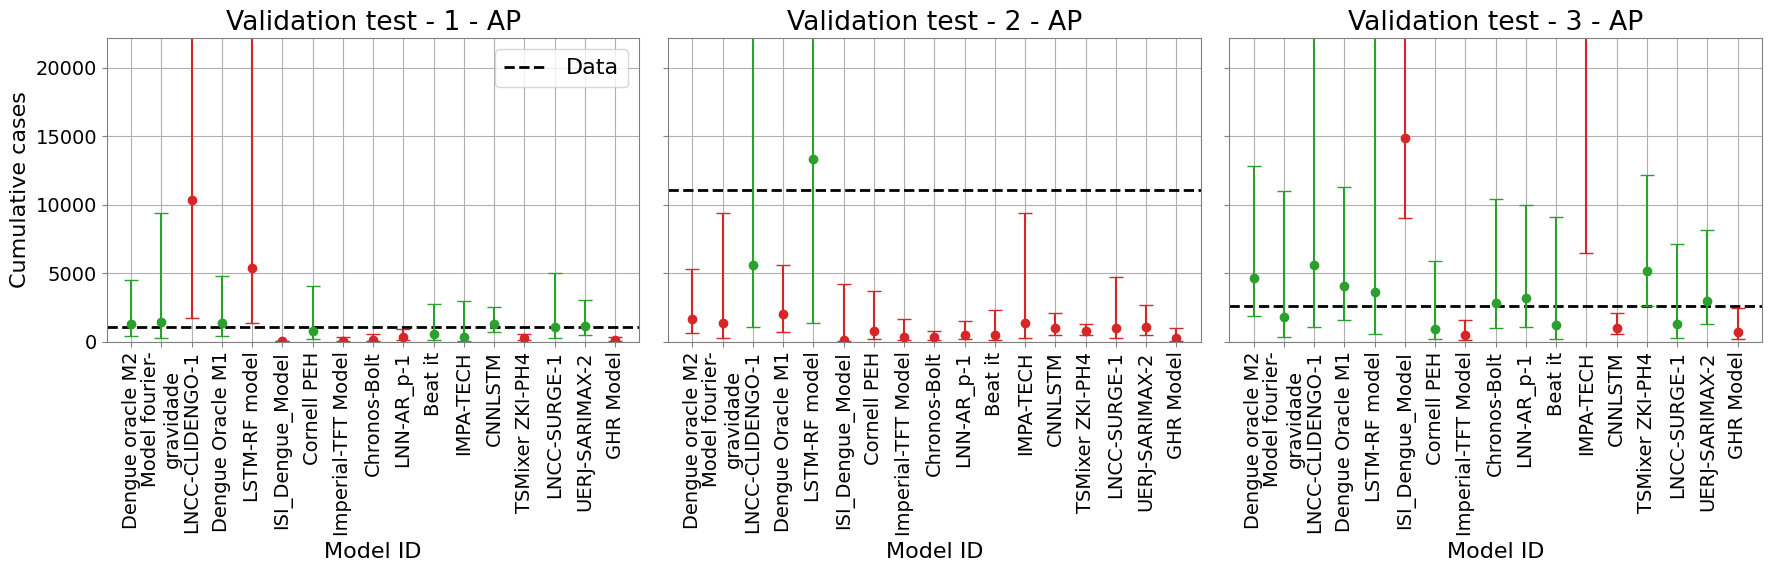

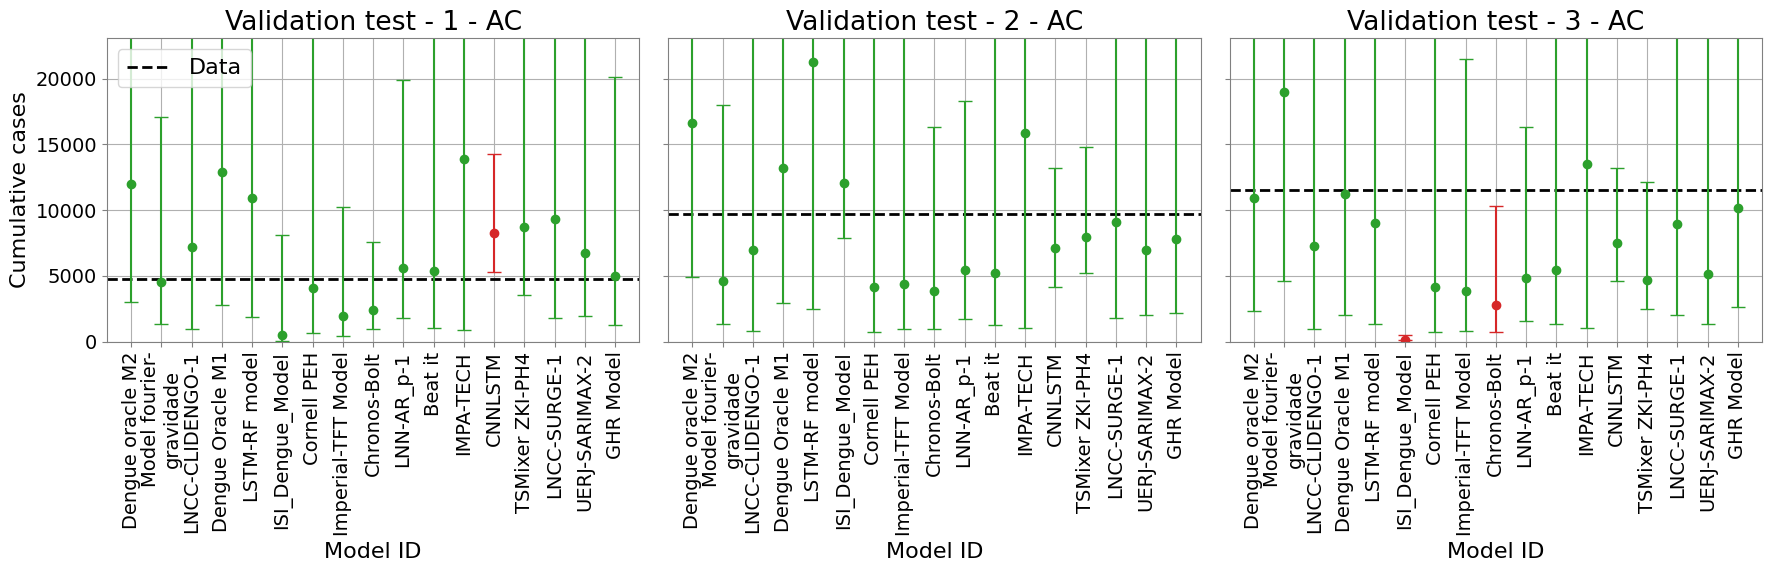

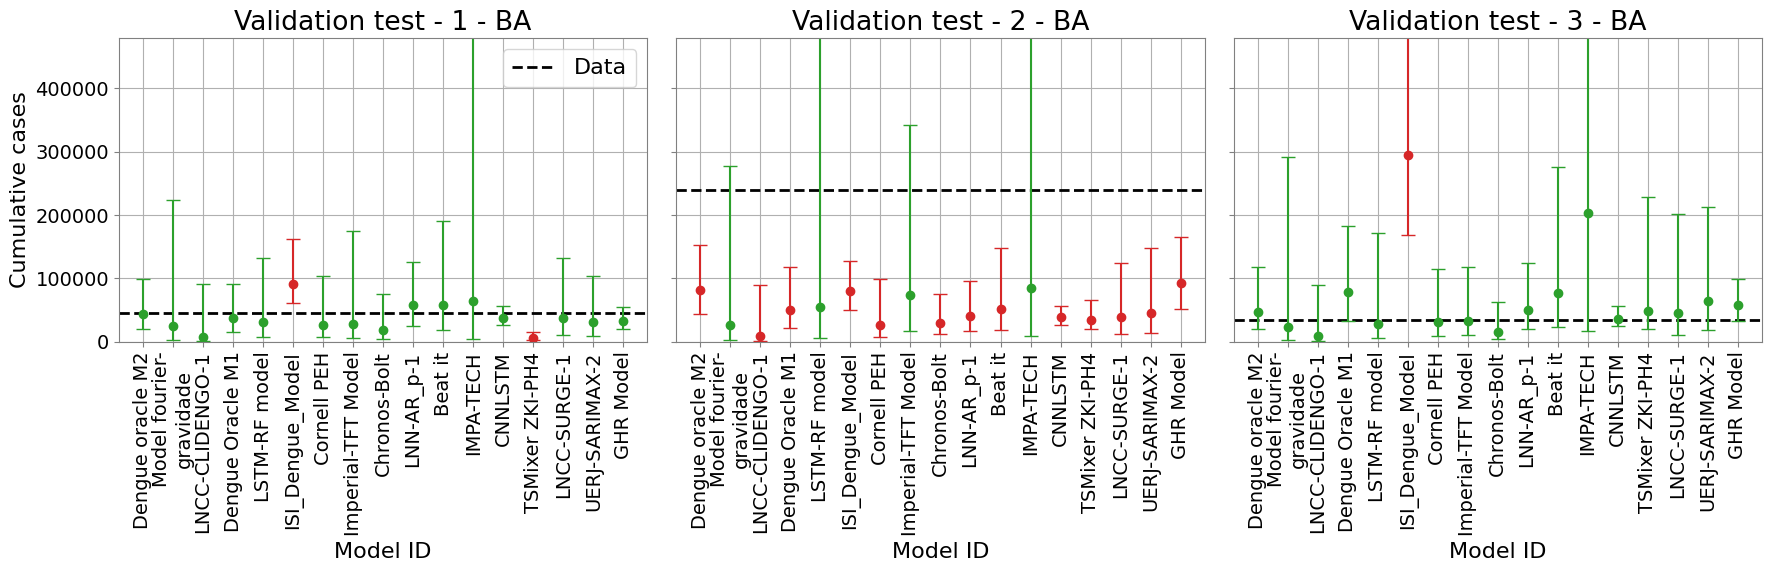

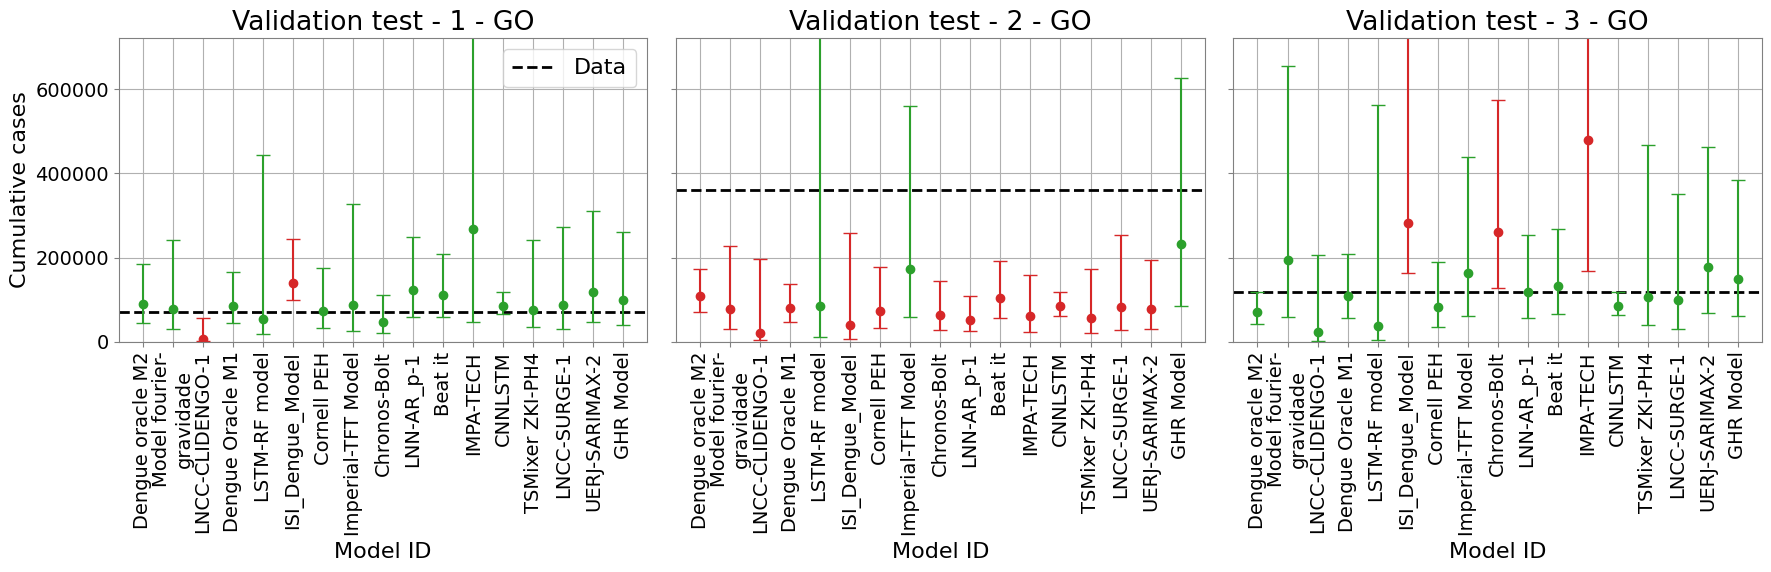

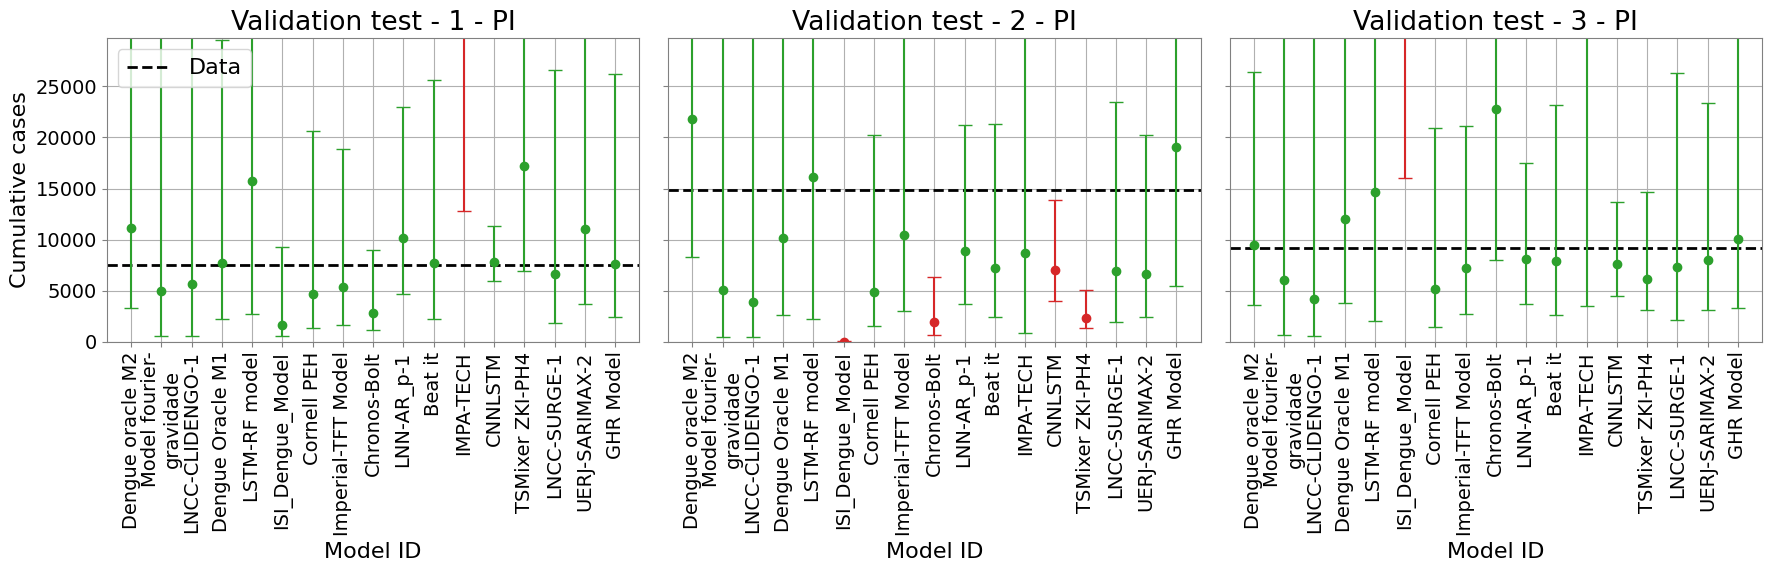

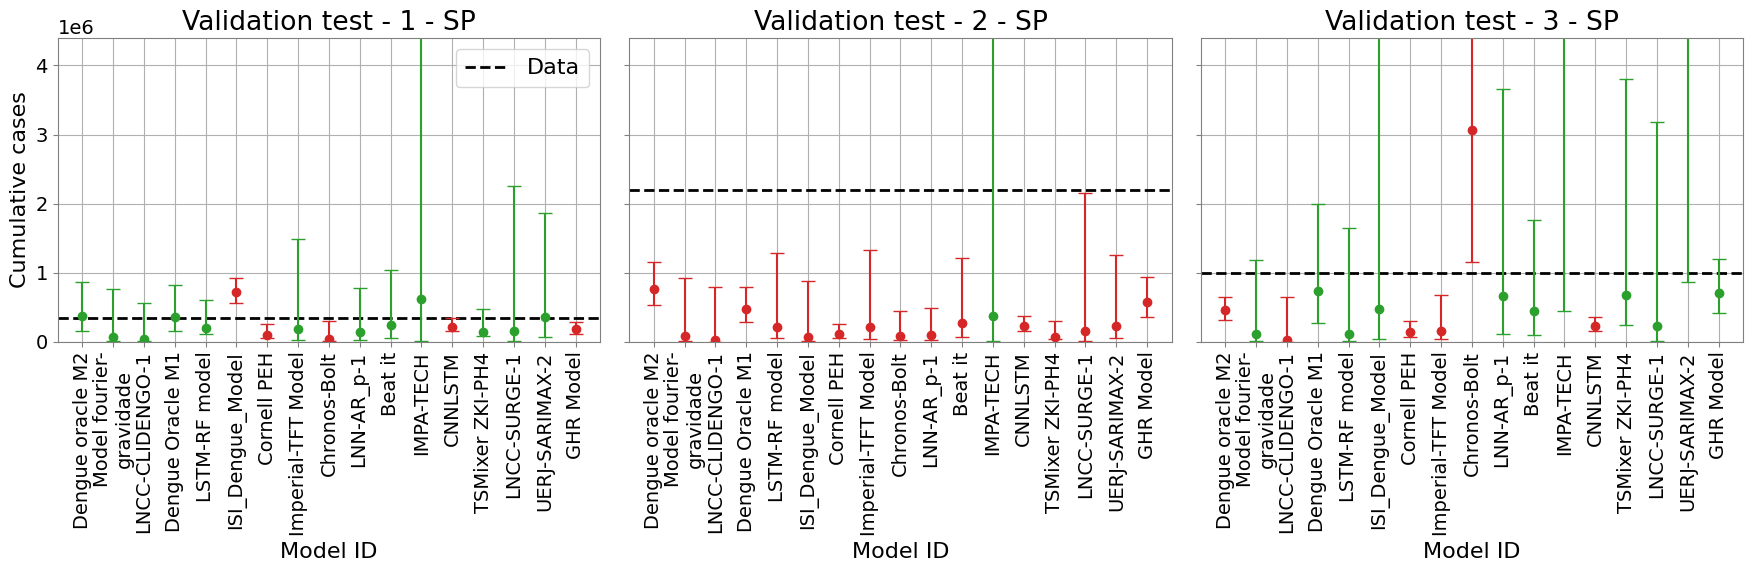

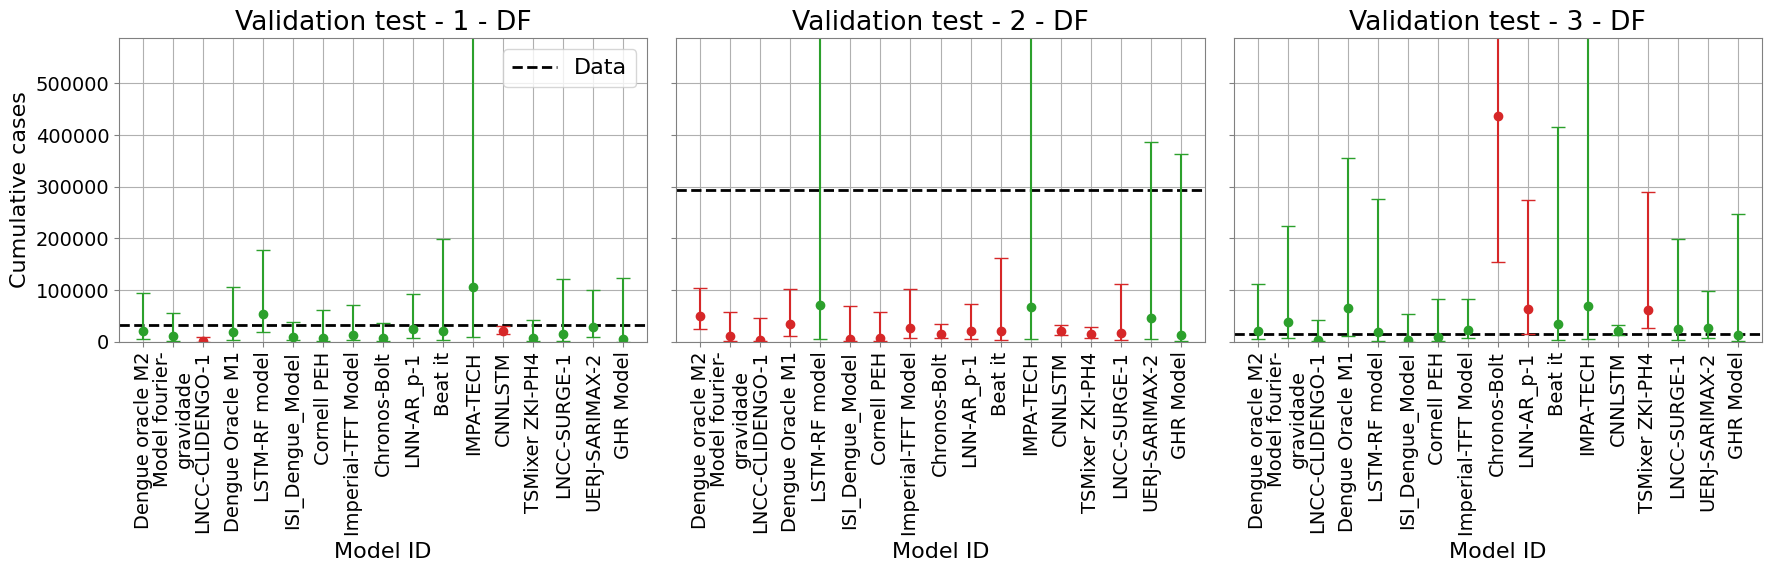

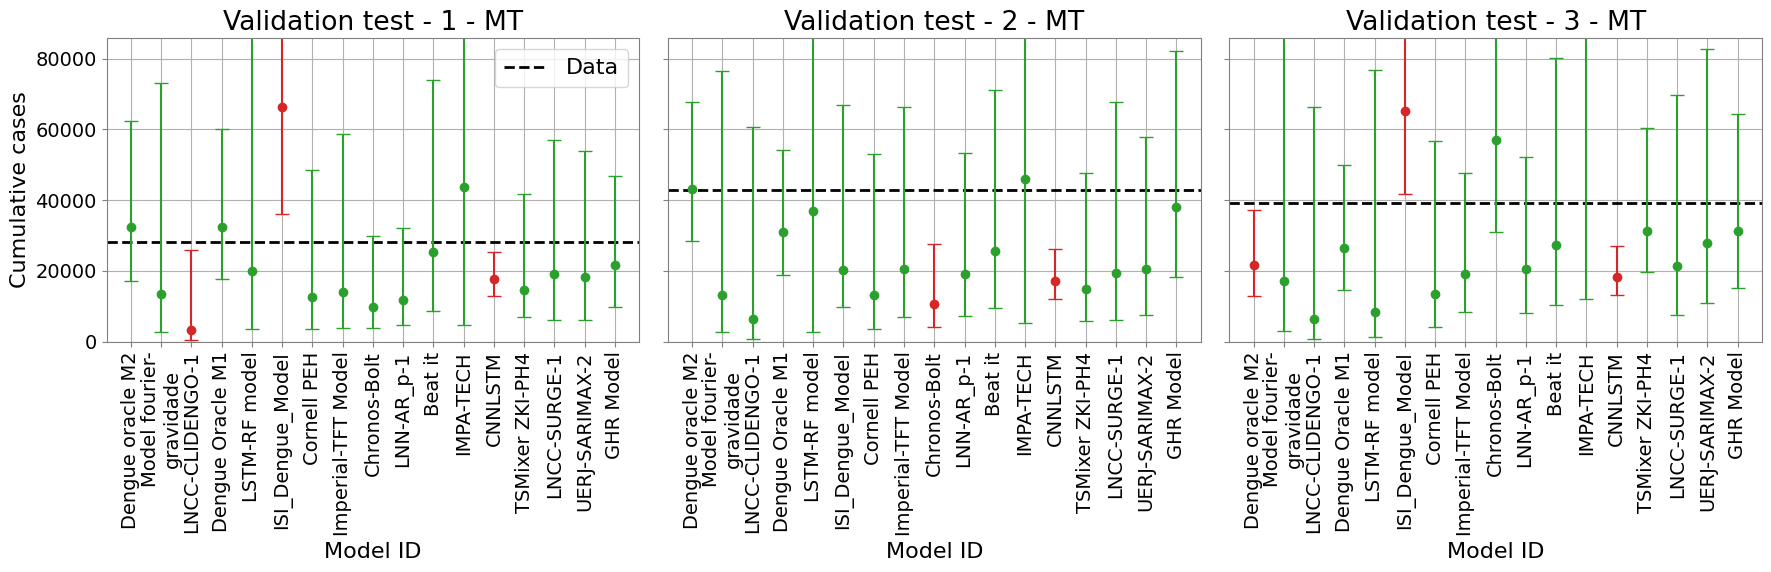

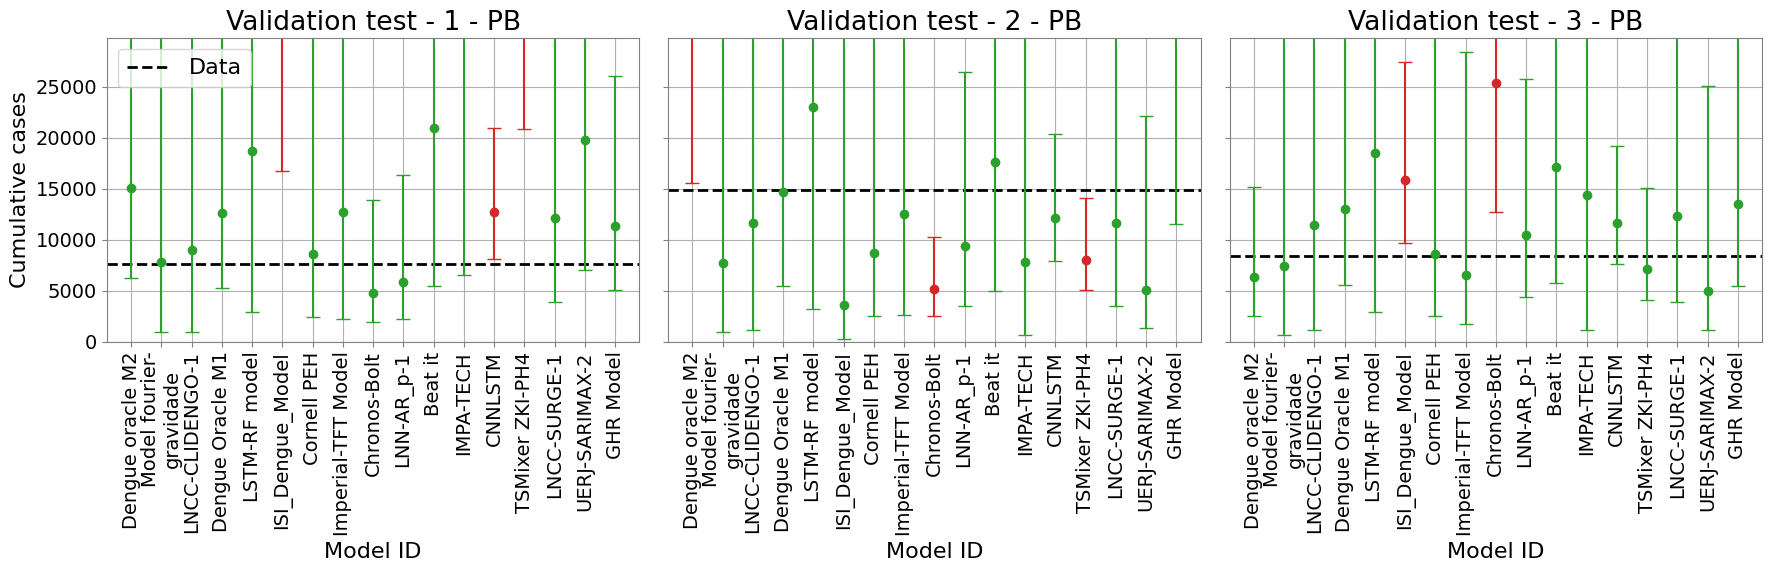

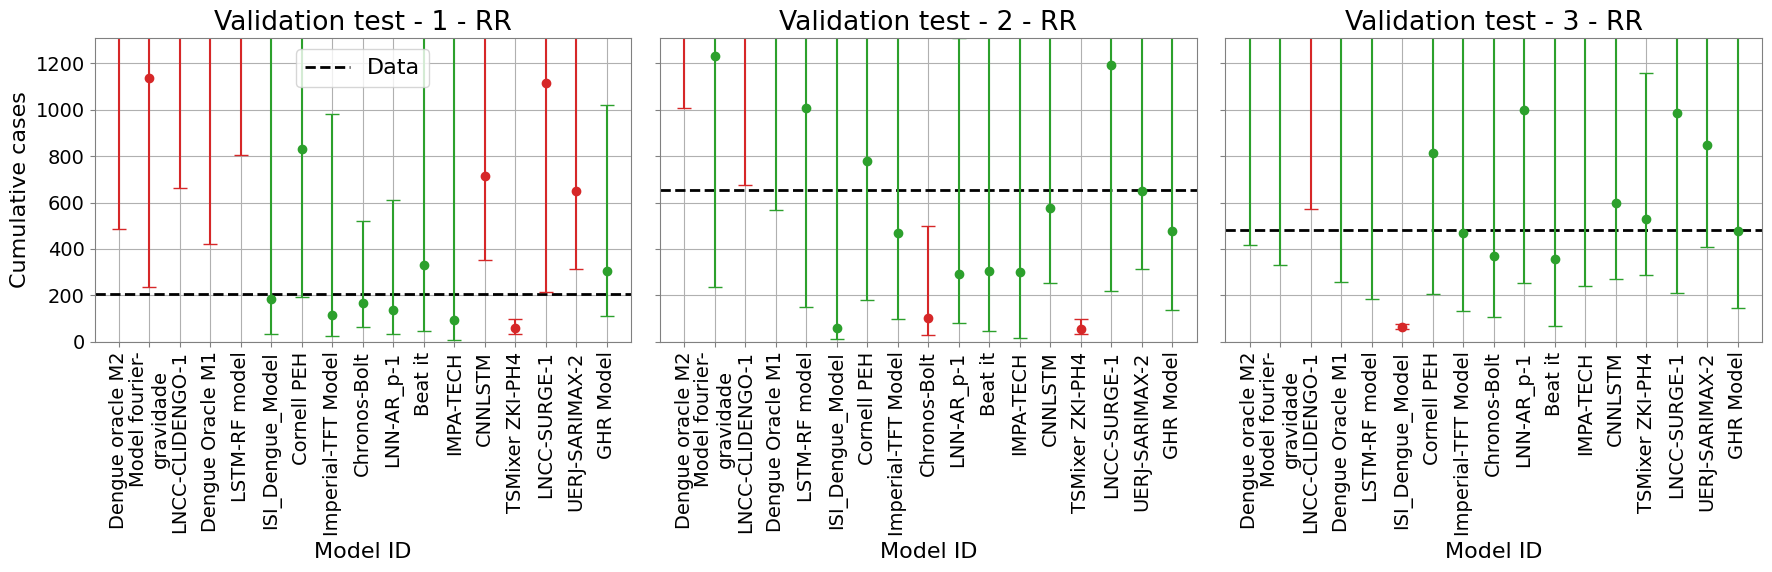

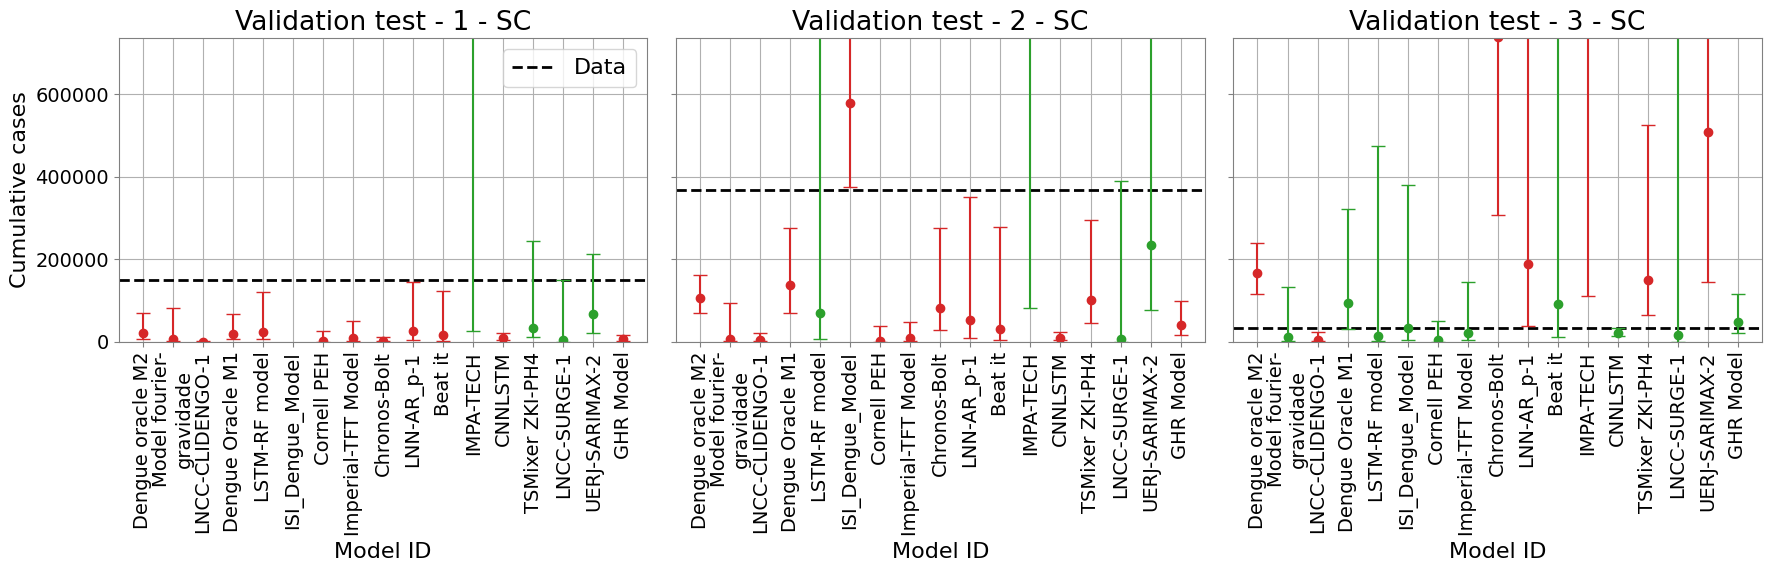

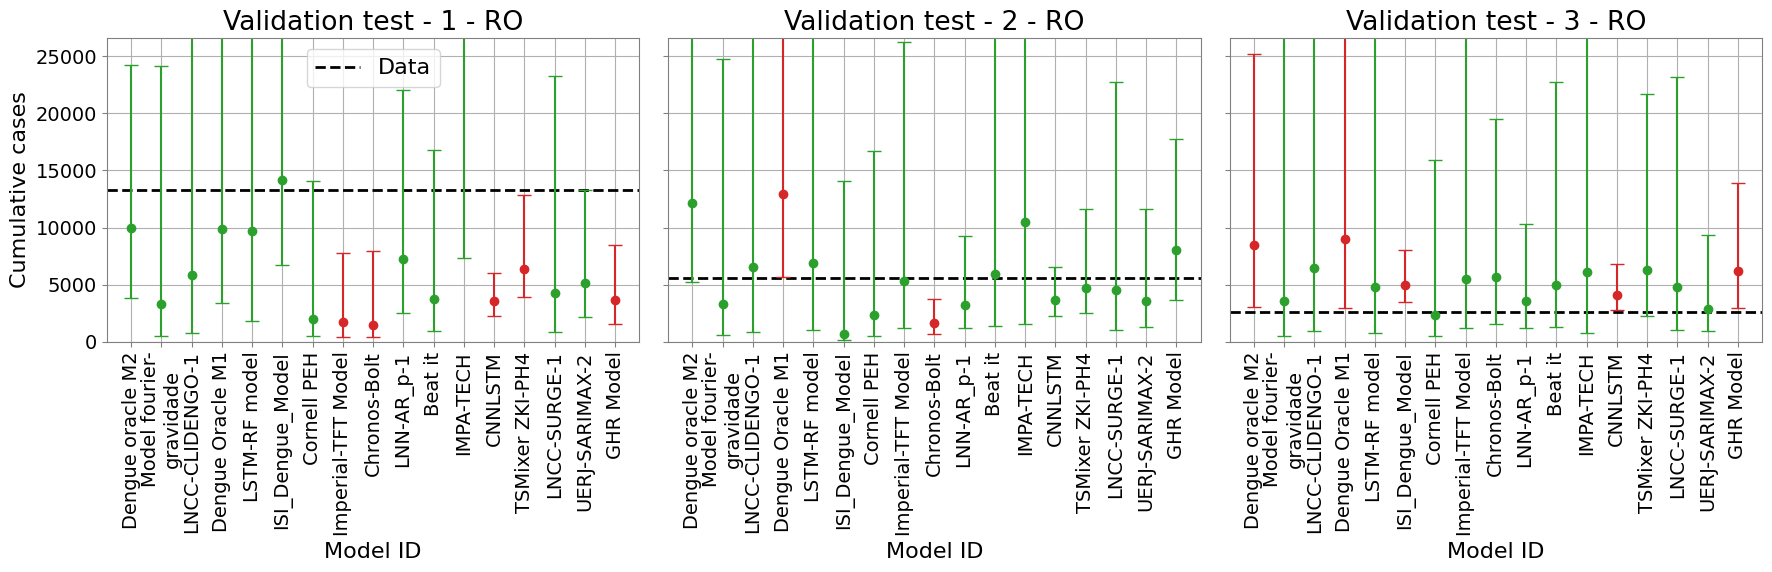

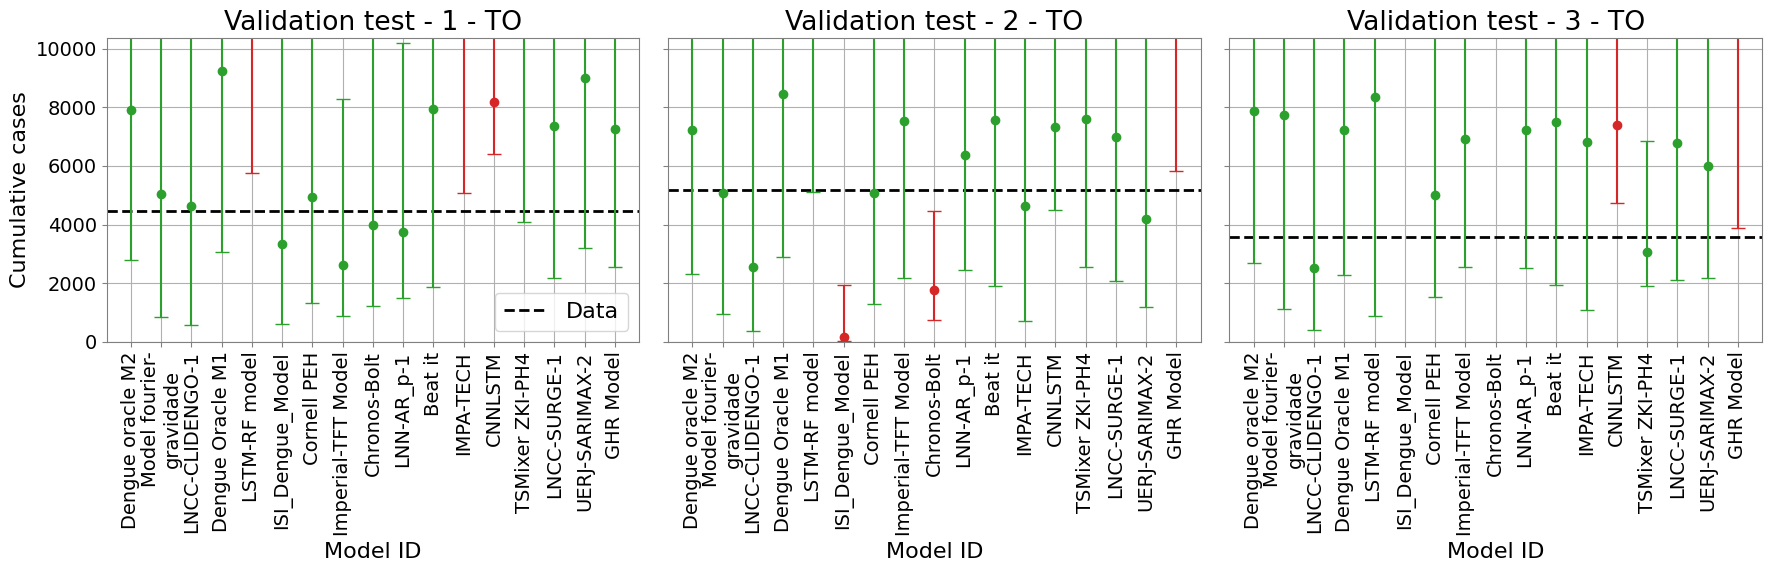

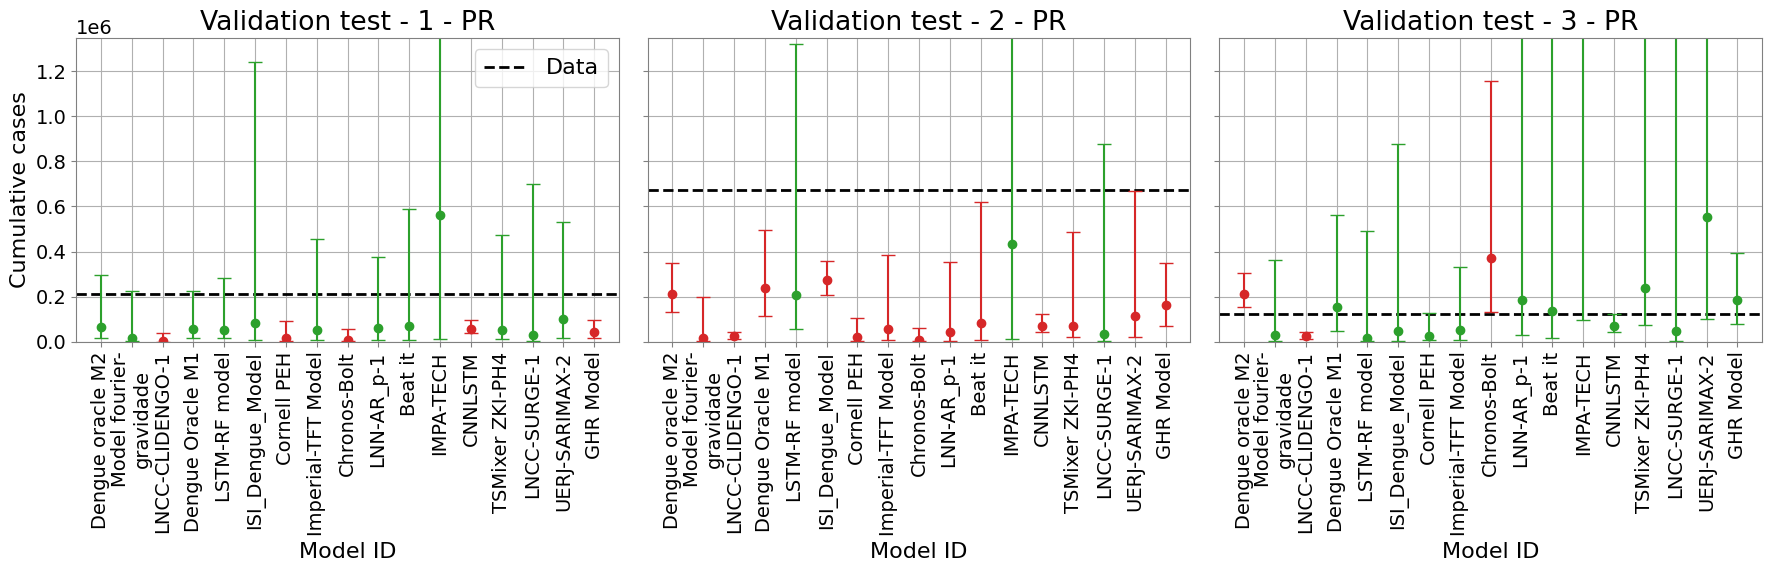

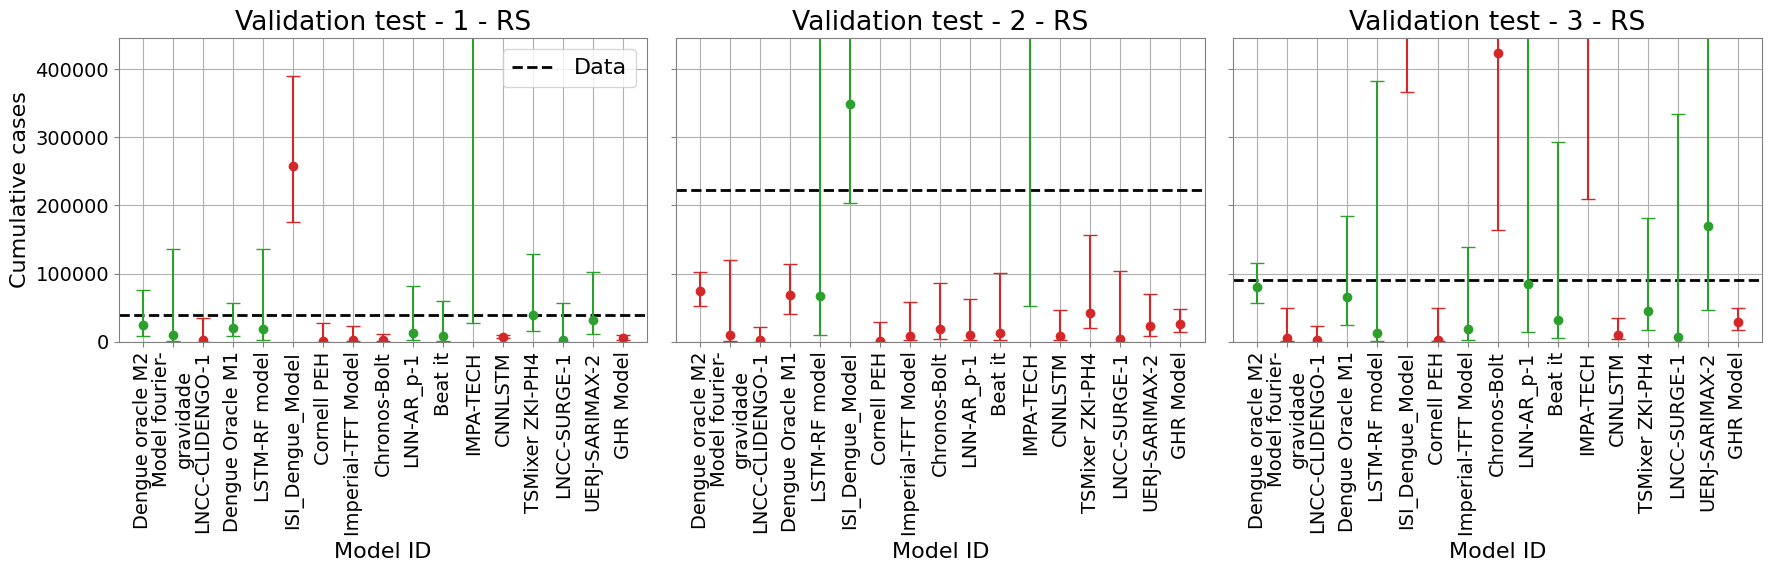

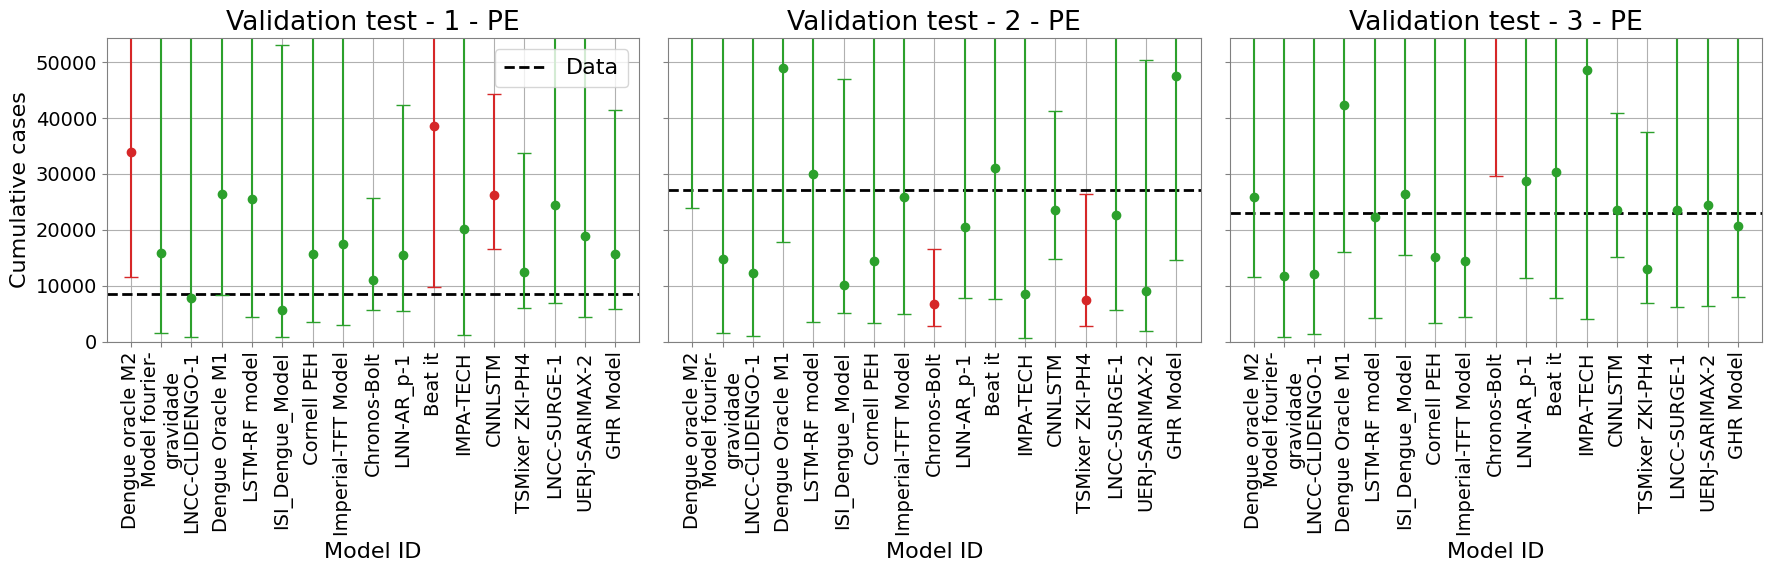

In [7]:
for state in df_cum_cases_agg.state.unique(): 
    _, ax = plt.subplots(1, 3, figsize = (18,6), sharey = True)
    
    make_plot(ax[0], df_cum_cases_agg, state= state, valid_test = 1)
    make_plot(ax[1], df_cum_cases_agg, state= state, valid_test = 2)
    make_plot(ax[2], df_cum_cases_agg, state= state, valid_test = 3)
    
    ax[1].legend().remove()
    ax[2].legend().remove()
    
    ax[1].set_ylabel('')
    ax[2].set_ylabel('')
    
    plt.tight_layout()
    
    plt.savefig(f'figures/total_cases_{state}.png', dpi = 400, bbox_inches = 'tight')
    
    plt.show()

Compute the model WIS:



In [8]:
from mosqlient.scoring import compute_wis

In [10]:
df_ = df_cum_cases_agg.copy()

df_['WIS'] = compute_wis(
                        df_[['lower_95', 'lower_90', 'lower_80', 'lower_50', 
                           'pred', 'upper_50', 'upper_80', 'upper_90', 'upper_95']],
                        observed_value = df_['casos'].values)

df_.head()

,state,model_id,valid_test,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,casos,WIS
0,AM,Dengue oracle M2,2,16759.842829,19701.124158,24026.087296,34369.616950,49203.015998,71907.113401,100553.149907,124257.278974,147251.373682,10105.0,22113.967915
1,AM,Dengue oracle M2,1,9769.876925,11925.533606,14740.430641,21691.115654,32157.557516,47498.268247,70680.881515,89337.838726,114652.778921,6279.0,14330.834806
2,AM,Dengue oracle M2,3,6896.698369,8399.579359,11136.912651,16783.524427,26255.407031,41140.491865,62087.388750,77388.479655,97357.538509,6150.0,10125.483069
3,AM,Model fourier-\ngravidade,2,628.165746,867.406998,1316.435844,2621.167780,5761.137645,12542.765440,26246.975856,40511.251908,62233.499865,10105.0,2370.602265
4,AM,Model fourier-\ngravidade,1,640.261728,891.307217,1293.693838,2610.876619,5735.525652,12229.364632,25173.544941,38695.322491,53439.963204,6279.0,1838.786131


In [11]:
df_[['model_id', 'state', 'valid_test', 'WIS']].to_csv('results/metrics_total_cases.csv', index = False)
